# RHI Predictor Test

Uses the trained models and the RHI results in the project `outputs/` folder.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'models').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_DIR = PROJECT_ROOT / 'models'
DATA_DIR = PROJECT_ROOT / 'data'
RHI_OUTPUT_DIR = PROJECT_ROOT / 'outputs'
TEST_OUTPUT_DIR = PROJECT_ROOT / 'outputs_test'
TEST_OUTPUT_DIR.mkdir(exist_ok=True)

model1 = joblib.load(MODEL_DIR / 'iri_prediction_model.pkl')
model2 = joblib.load(MODEL_DIR / 'fwd_health_model.pkl')
le_target = joblib.load(MODEL_DIR / 'fwd_label_encoder.pkl')

print('Models loaded successfully.')

Models loaded successfully.


In [2]:
# Recreate the categorical encoders used by the FWD training workflow.
fwd = pd.read_excel(DATA_DIR / 'MON_DEFL_DROP_DATA.xlsx')
exp = pd.read_excel(DATA_DIR / 'EXPERIMENT_SECTION.xlsx')

fwd['SHRP_ID'] = fwd['SHRP_ID'].astype(str).str.zfill(4)
exp_clean = exp[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'PAVEMENT_FAMILY']].drop_duplicates()
fwd = fwd.drop(columns=['PEAK_DEFL_9', 'NON_DECREASING_DEFL', 'STATE_CODE_EXP',
                        'LANE_NO_EXP', 'DROP_HEIGHT_EXP', 'DEFL_UNIT_ID'], errors='ignore')
fwd_features = pd.merge(
    fwd, exp_clean, on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'], how='inner'
).drop(columns=['PEAK_DEFL_8', 'NON_DECREASING_DEFL_EXP'], errors='ignore').dropna()

pavement_encoder = LabelEncoder().fit(fwd_features['PAVEMENT_FAMILY'])
lane_encoder = LabelEncoder().fit(fwd_features['LANE_NO'])

print('Pavement families:', list(pavement_encoder.classes_))
print('Lane types:', list(lane_encoder.classes_))

Pavement families: ['ACTB', 'ACUB']
Lane types: ['F1', 'F3']


In [3]:
features1 = ['MRI', 'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND',
             'ANNUAL_ESAL_TREND', 'CUMULATIVE_ESAL', 'IRI_GROWTH_RATE', 'YEAR']
features2 = ['PEAK_DEFL_1', 'PEAK_DEFL_2', 'PEAK_DEFL_3', 'PEAK_DEFL_4',
             'PEAK_DEFL_5', 'PEAK_DEFL_6', 'PEAK_DEFL_7', 'DROP_LOAD',
             'DROP_HEIGHT', 'PAVEMENT_FAMILY_ENC', 'LANE_NO_ENC']

def predict_rhi(sample):
    """Return IRI, FWD, and combined RHI predictions for one road sample."""
    unknown_pavement = set([sample['pavement_family']]) - set(pavement_encoder.classes_)
    unknown_lane = set([sample['lane_no']]) - set(lane_encoder.classes_)
    if unknown_pavement or unknown_lane:
        raise ValueError(f'Unsupported category: pavement={unknown_pavement}, lane={unknown_lane}')

    iri_input = pd.DataFrame([[
        sample['mri'], sample['aadtt'], sample['annual_truck_volume'],
        sample['annual_esal'], sample['cumulative_esal'], sample['iri_growth_rate'],
        sample['year']
    ]], columns=features1)
    predicted_iri = float(model1.predict(iri_input)[0])
    failure_threshold = 2.5
    iri_score = float(np.clip(
        ((failure_threshold - predicted_iri) / failure_threshold) * 100, 0, 100
    ))

    fwd_input = pd.DataFrame([[
        *sample['deflections'], sample['drop_load'], sample['drop_height'],
        pavement_encoder.transform([sample['pavement_family']])[0],
        lane_encoder.transform([sample['lane_no']])[0]
    ]], columns=features2)
    health_code = model2.predict(fwd_input).astype(int)
    health = le_target.inverse_transform(health_code)[0]
    fwd_score = {'Good': 100, 'Fair': 60, 'Poor': 20}[health]

    rhi = (iri_score + fwd_score) / 2
    condition = 'Good' if rhi >= 75 else 'Fair' if rhi >= 50 else 'Poor'
    return {
        'predicted_future_iri': predicted_iri,
        'iri_score': iri_score, 'fwd_health': health, 'fwd_score': fwd_score,
        'rhi': rhi, 'road_condition': condition
    }

In [4]:
# Sample input using representative IRI, traffic, and FWD values.
sample = {
    'mri': 0.85,
    'aadtt': 950,
    'annual_truck_volume': 346750,
    'annual_esal': 310000,
    'cumulative_esal': 1500000,
    'iri_growth_rate': 0.012,
    'year': 2025,
    'deflections': [450, 280, 210, 180, 140, 110, 70],
    'drop_load': 710,
    'drop_height': 4,
    'pavement_family': 'ACUB',
    'lane_no': 'F3',
}

sample_result = pd.DataFrame([predict_rhi(sample)])
sample_result.to_csv(TEST_OUTPUT_DIR / 'sample_prediction.csv', index=False)
display(sample_result.round(2))
print(f'Saved sample prediction to {TEST_OUTPUT_DIR / "sample_prediction.csv"}')

,predicted_future_iri,iri_score,fwd_health,fwd_score,rhi,road_condition
0,0.89,64.56,Good,100,82.28,Good


Saved sample prediction to C:\Users\harsh\OneDrive\Desktop\Road-RSL-Prediction\outputs_test\sample_prediction.csv


In [5]:
# Statistical summary of all section-level RHI predictions.
rhi_scores_path = RHI_OUTPUT_DIR / 'rhi_scores.csv'
if not rhi_scores_path.exists():
    raise FileNotFoundError(f'RHI results file not found: {rhi_scores_path}. Run RHI_Score.ipynb first.')

rhi_scores = pd.read_csv(rhi_scores_path)
summary = rhi_scores[['IRI_SCORE', 'FWD_SCORE', 'RHI']].describe().T
condition_counts = rhi_scores['ROAD_CONDITION'].value_counts().rename_axis('ROAD_CONDITION').reset_index(name='COUNT')

summary.round(2).to_csv(TEST_OUTPUT_DIR / 'rhi_statistical_summary.csv')
condition_counts.to_csv(TEST_OUTPUT_DIR / 'rhi_condition_counts.csv', index=False)
display(summary.round(2))
display(condition_counts)
print(f'Sections analyzed: {len(rhi_scores)}')
print(f'Average RHI: {rhi_scores["RHI"].mean():.2f}')
print(f'RHI standard deviation: {rhi_scores["RHI"].std():.2f}')
print(f'Saved statistical tables to {TEST_OUTPUT_DIR}')

,count,mean,std,min,25%,50%,75%,max
IRI_SCORE,5.0,54.37,7.35,43.33,53.17,54.41,57.45,63.48
FWD_SCORE,5.0,96.25,5.34,87.76,94.14,99.66,99.69,100.00
RHI,5.0,75.31,6.18,65.55,73.65,77.05,78.55,81.74


,ROAD_CONDITION,COUNT
0,Good,3
1,Fair,2


Sections analyzed: 5
Average RHI: 75.31
RHI standard deviation: 6.18
Saved statistical tables to C:\Users\harsh\OneDrive\Desktop\Road-RSL-Prediction\outputs_test


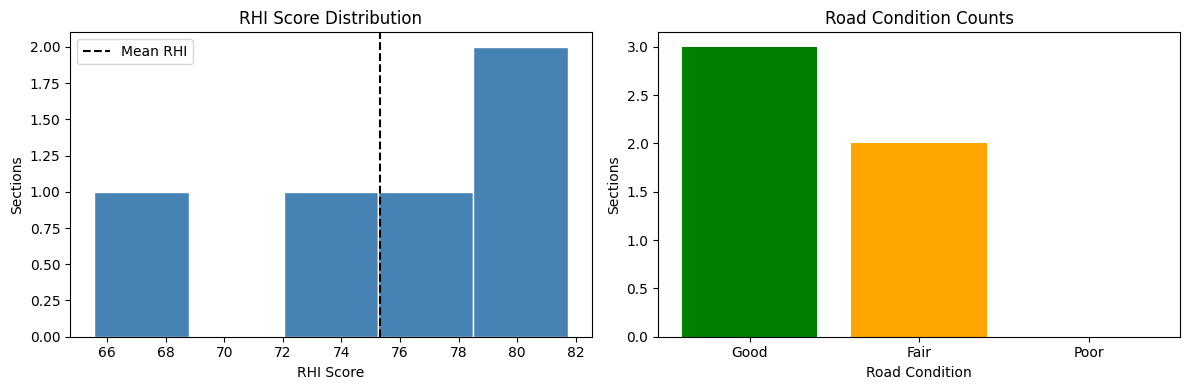

In [6]:
# Visual statistical checks for RHI distribution and road-condition mix.
condition_order = ['Good', 'Fair', 'Poor']
condition_counts = rhi_scores['ROAD_CONDITION'].value_counts().reindex(condition_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rhi_scores['RHI'], bins=min(10, len(rhi_scores)), color='steelblue', edgecolor='white')
axes[0].axvline(rhi_scores['RHI'].mean(), color='black', linestyle='--', label='Mean RHI')
axes[0].set(title='RHI Score Distribution', xlabel='RHI Score', ylabel='Sections')
axes[0].legend()

axes[1].bar(condition_counts.index, condition_counts.values, color=['green', 'orange', 'red'])
axes[1].set(title='Road Condition Counts', xlabel='Road Condition', ylabel='Sections')

plt.tight_layout()
plt.savefig(TEST_OUTPUT_DIR / 'rhi_test_statistics.png', dpi=150)
plt.show()